数据集CPI 
z_baomatch = z_bao
mB_baomatch_CPI mB_baomatch_cov_CPI
bao_val bao_cov
但前三个点需要特殊处理

z_ccmatch = z_cc
mB_ccmatch_CPI mB_ccmatch_cov_CPI
cc_val cc_cov
da_cc da_cc_cov

In [1]:
import numpy as np
import emcee
import corner
import matplotlib.pyplot as plt
from scipy.stats import chi2
import utils
np.random.seed(42)

is_dv = [True, True, True, False, False, False, False, False, False, False, False] # marker to DV/rd

z_bao, bao_val, _ = np.loadtxt('data/bao_data.dat', unpack=True)
bao_cov = np.loadtxt("output/bao_cov.txt")

_, cc_dv_val, cc_dv_err = np.loadtxt('output/Hz_DVreconstruct_results.txt', unpack=True)
cc_dv_cov = np.loadtxt("output/cc_cov_atonlydv.txt")

full_h_cov = np.zeros((11, 11))
full_h_cov[0:3, 0:3] = cc_dv_cov
cc_dv_cov = full_h_cov

mB_baomatch = np.load("output/mB_baomatch_mean_GPR.npy")
mB_baomatch_cov = np.load("output/mB_baomatch_cov_GPR.npy")

z_cc, cc_val, cc_err = np.loadtxt('data/cc.txt', unpack=True)

da_cc = np.load('output/da_cc.npy')
da_cc_cov = np.load('output/da_cc_cov.npy')

mB_ccmatch = np.load("output/mB_ccmatch_mean_GPR.npy")
mB_ccmatch_cov = np.load("output/mB_ccmatch_cov_GPR.npy")

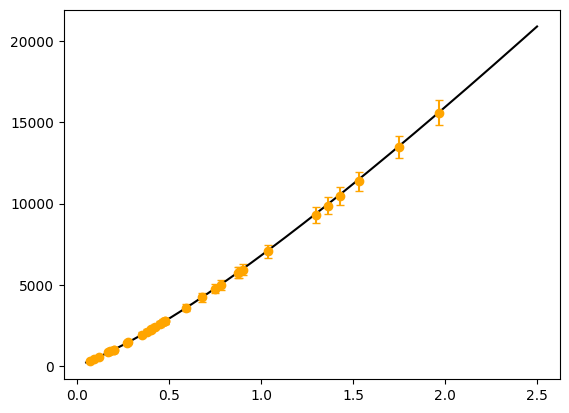

In [2]:
from astropy.cosmology import FlatLambdaCDM
z_plot = np.linspace(0.05, 2.5, 200)
cosmo = FlatLambdaCDM(H0=67.4, Om0=0.315)
DL = cosmo.luminosity_distance(z_plot).value 
plt.errorbar(z_cc, da_cc*(1+z_cc)**2, yerr=np.sqrt(np.diag(da_cc_cov))*(1+z_cc)**2, fmt='o', color='orange', 
             ecolor='orange', capsize=3, label='Derived $D_A$ at CC points')
plt.plot(z_plot, DL, color='black', label=r'$\Lambda$CDM')

In [ ]:
def eta_model_linear(z, eta_1):
    return 1 + eta_1 * z

def eta_model_fractional(z, eta_2):
    return 1 + (eta_2 * z) / (1 + z)

def eta_model_logarithmic(z, eta_3):
    return 1 + eta_3 * np.log(1 + z)

def eta_model_powerlaw(z, eps):
    return (1+z)**eps

MODEL = eta_model_powerlaw 

def construct_covariance_bao(z, eta_vec, mB_cov, bao_val, bao_cov, cc_val, cc_cov, is_dv):
    N = len(z)
    const = np.log(10) / 5.0
    
    # --- 1. mB 贡献部分 ---
    # J_mB 是对角阵，元素为 eta * const
    J_mB = np.diag(eta_vec * const)
    C_part_mB = J_mB @ mB_cov @ J_mB.T
    
    # --- 2. BAO 贡献部分 ---
    # 计算 BAO 的 Jacobian 权重
    w_bao = np.zeros(N)
    for i in range(N):
        if is_dv[i]:
            w_bao[i] = -1.5 * eta_vec[i] / bao_val[i]
        else:
            w_bao[i] = -1.0 * eta_vec[i] / bao_val[i]
    J_bao = np.diag(w_bao)
    C_part_bao = J_bao @ bao_cov @ J_bao.T
    
    # --- 3. Hz 贡献部分 ---
    w_h = np.zeros(N)
    for i in range(N):
        if is_dv[i]:
            # 只有 DV 点受 H 影响
            w_h[i] = -0.5 * eta_vec[i] / cc_val[i]
        else:
            w_h[i] = 0.0
    J_h = np.diag(w_h)
    C_part_h = J_h @ cc_cov @ J_h.T
    
    return C_part_mB + C_part_bao + C_part_h

def construct_covariance_cc(z, eta_vec, mB_cov, da_val, da_cov):
    """ CC 的协方差构建 32*32"""
    N = len(z)
    const = np.log(10) / 5.0

    # mB 部分
    J_mB = np.diag(eta_vec * const)
    C_part_mB = J_mB @ mB_cov @ J_mB.T

    # DA 部分 (eta 与 DA 成反比 -> 导数为 -eta/DA)
    w_da = -1.0 * eta_vec / da_val
    J_da = np.diag(w_da)
    C_part_da = J_da @ da_cov @ J_da.T

    return C_part_mB + C_part_da


# ==========================================
# 3. 构建似然函数与 MCMC 逻辑
# ==========================================

def get_eta_obs_bao(theta, z, bao_val, cc_val, mB_match, is_dv):
    """BAO 观测值计算 """
    eta0, MB, rd = theta
    c_light = 299792.458
    DL_sn = 10**((mB_match - MB - 25) / 5.0)
    
    eta_obs = np.zeros(len(z))
    for i in range(len(z)):
        if is_dv[i]:
            dm_eff = np.sqrt((bao_val[i]**3 * rd**3 * cc_val[i]) / (z[i] * c_light))
            eta_obs[i] = DL_sn[i] / (dm_eff * (1 + z[i]))
        else:
            eta_obs[i] = DL_sn[i] / (bao_val[i] * rd * (1 + z[i]))
    return eta_obs

def get_eta_obs_cc(theta, z, da_val, mB_match):
    """ CC 观测值计算 """
    eta0, MB, rd = theta # 这里不需要 rd，但保持接口一致
    
    DL_sn = 10**((mB_match - MB - 25) / 5.0)
    # CDDR: eta = DL / ((1+z)^2 * DA)
    eta_obs = DL_sn / ((1 + z)**2 * da_val)
    
    return eta_obs

def ln_prior(theta):
    eta0, MB, rd = theta
    # if not (-1 < eta0 < 1):
    #     return -np.inf
    # MB_mean, MB_sigma = -19.253, 0.027
    # MB_mean, MB_sigma = -19.384, 0.052
    # rd_mean, rd_sigma = 147.09, 0.26
    
    # lnP_MB = -0.5 * ((MB - MB_mean)/MB_sigma)**2
    # lnP_rd = -0.5 * ((rd - rd_mean)/rd_sigma)**2
    if -1.0 < eta0 < 1.0 and -20.0 < MB < -18.0 and 130.0 < rd < 200.0:
        return 0.0

    return -np.inf

def ln_likelihood(theta, 
                  z_bao, mB_match, mB_cov, bao_val, bao_cov, cc_val, cc_cov, is_dv, # BAO 参数
                  z_cc, mB_ccmatch, mB_cov_cc, da_cc, da_cc_cov, MODEL):            # CC 参数
    
    eta0, MB, rd = theta
    
    # --- Part 1: BAO 计算 ---
    eta_obs_bao = get_eta_obs_bao(theta, z_bao, bao_val, cc_val, mB_match, is_dv)
    C_bao = construct_covariance_bao(z_bao, eta_obs_bao, mB_cov, bao_val, bao_cov, cc_val, cc_cov, is_dv)
    
    eta_th_bao = MODEL(z_bao, eta0)
    res_bao = eta_obs_bao - eta_th_bao
    
    inv_C_bao = np.linalg.inv(C_bao)
    sign_b, logdet_bao = np.linalg.slogdet(C_bao)
    ln_L_bao = -0.5 * (res_bao.T @ inv_C_bao @ res_bao + logdet_bao)

    # --- Part 2: CC 计算 ---
    eta_obs_cc = get_eta_obs_cc(theta, z_cc, da_cc, mB_ccmatch)
    C_cc = construct_covariance_cc(z_cc, eta_obs_cc, mB_cov_cc, da_cc, da_cc_cov)

    eta_th_cc = MODEL(z_cc, eta0)
    res_cc = eta_obs_cc - eta_th_cc

    inv_C_cc = np.linalg.inv(C_cc)
    sign_c, logdet_cc = np.linalg.slogdet(C_cc)
    ln_L_cc = -0.5 * (res_cc.T @ inv_C_cc @ res_cc + logdet_cc)

    return ln_L_bao # +  ln_L_cc

def ln_probability(theta, *args):
    lp = ln_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + ln_likelihood(theta, *args)

# ==========================================
# 4. 运行 emcee 采样
# ==========================================
args = (z_bao, mB_baomatch, mB_baomatch_cov, bao_val, bao_cov, cc_dv_val, cc_dv_cov, is_dv,
        z_cc, mB_ccmatch, mB_ccmatch_cov, da_cc, da_cc_cov, MODEL)

nwalkers = 32
ndim = 3
pos = [0.0, -19.38, 147.0] + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, ln_probability, args=args)

print("running MCMC with BAO + CC ...")
sampler.run_mcmc(pos, 5000, progress=True)

# 丢弃前1000步 Burn-in
samples = sampler.get_chain(discard=1000, flat=True)

# ==========================================
# 5. 结果展示与保存
# ==========================================
# 保存链以便以后分析
np.save("output/joint_constraint_chain.npy", samples)

# 打印参数限制结果 (16, 50, 84 分位数)
labels = [r"$\eta_0$", r"$M_B$", r"$r_d$"]
for i in range(ndim):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{labels[i]}: {mcmc[1]:.4f} (+{q[1]:.4f}, -{q[0]:.4f})")

# 画 Corner Plot
fig = corner.corner(samples, labels=labels, truths=[0.0, -19.38, 147.09],
                    show_titles=True, title_fmt=".3f", 
                    quantiles=[0.16, 0.5, 0.84], color='darkblue')
fig.savefig("fig/joint_constraint_corner.pdf")
plt.show()

In [ ]:
print(sampler.get_autocorr_time())

[37.04904002 38.0191908  38.13919632]


Removed no burn in


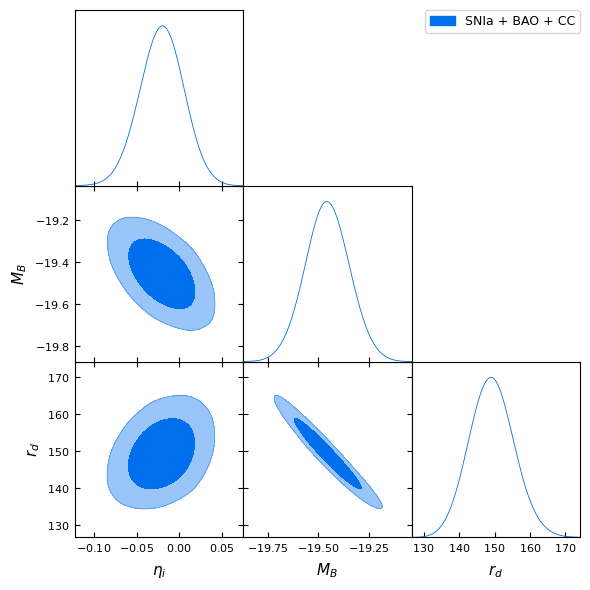

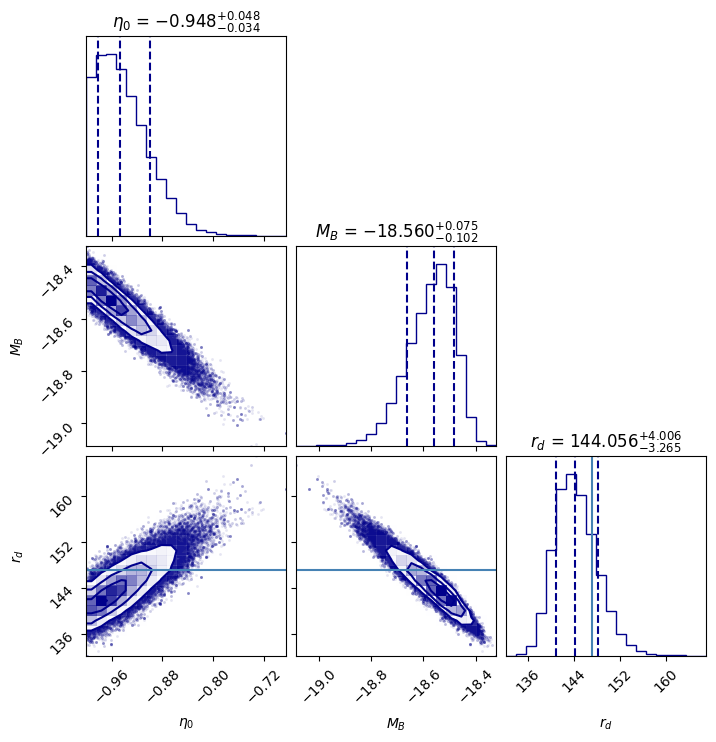

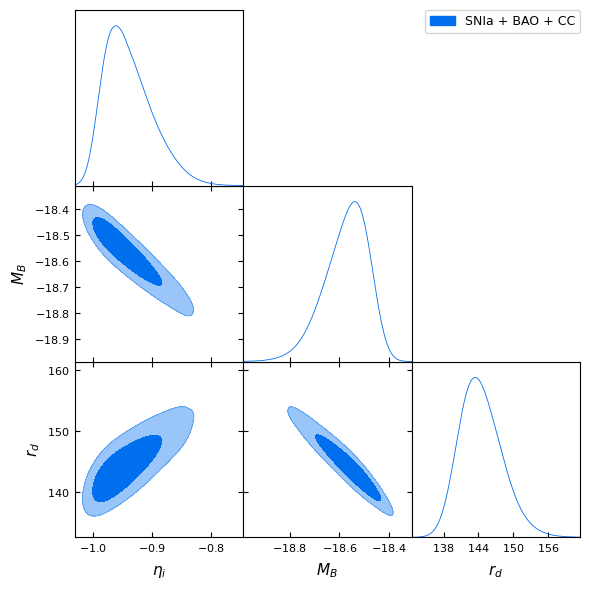

In [ ]:
%matplotlib inline
from getdist import MCSamples, plots
names  = ["etai", "MB", "rd"]
labels = [r"\eta_i", r"M_B", r"r_d"]
gdsamples = MCSamples(
    samples=samples,
    names=names,
    labels=labels
)
gdsamples.updateSettings({
    'smooth_scale_1D': 0.5,
    'smooth_scale_2D': 0.5
})
g = plots.get_subplot_plotter()
g.triangle_plot(gdsamples, filled=True, legend_labels=["SNIa + BAO + CC"])

In [ ]:
theta = [0,-19.43,143]
eta_obs_cc = get_eta_obs_cc(theta, z_cc, da_cc, mB_ccmatch)
print('eta_obs_cc:', eta_obs_cc)
eta_th_cc = MODEL(z_cc, -0.2)
print('eta_th_cc:', eta_th_cc)
eta_obs_bao = get_eta_obs_bao(theta, z_bao, bao_val, cc_val, mB_baomatch, is_dv)
print(eta_obs_bao)
eta_th_bao = MODEL(z_bao, -0.2)
res_bao = eta_obs_cc - eta_th_cc
print(res_bao)

eta_obs_cc: [0.97610216 0.97907214 0.98308849 0.98764298 0.9881899  0.98917468
 0.98921713 0.9905592  0.99055779 0.98966078 0.98902313 0.9885163
 0.98850568 0.9878355  0.98711342 0.9865106  0.98626305 0.98621167
 0.98294174 0.98079015 0.97937572 0.97884133 0.9775456  0.97748942
 0.97727606 0.97624669 0.9755066  0.97539919 0.97526236 0.97496237
 0.97357932 0.97073891]
eta_th_cc: [0.98655941 0.98291214 0.9775892  0.96908713 0.96760307 0.96435328
 0.9641925  0.95332121 0.95182697 0.94146605 0.93758704 0.93491988
 0.93486646 0.93165542 0.92841975 0.92584126 0.92479928 0.92458673
 0.9110807  0.90144274 0.89411296 0.89097848 0.88186021 0.88139063
 0.87952721 0.8673648  0.84655355 0.84199062 0.83729548 0.83056934
 0.81683335 0.80462785]
[1.07051106 1.01218942 1.13695062 1.03958642 1.00715031 1.0253425
 1.05045641 1.01753409 1.01127277 0.98663231 1.01321732]
[-0.01045725 -0.00384     0.00549929  0.01855584  0.02058683  0.0248214
  0.02502463  0.03723799  0.03873082  0.04819474  0.05143609  0.0